# GCM → IMD Monthly Downscaling + Bias Correction (0.25° · India)

**Pipeline (precipitation):**
1. **Cell 1** – Setup, paths, config
2. **Cell 2** – Discover input files + auto-detect variable / coordinate names
3. **Cell 3** – Monthly aggregation: **GCM daily → monthly** (saved)
4. **Cell 4** – Monthly aggregation: **IMD daily → monthly** (saved)
5. **Cell 5** – Region grid + shapefile mask + elevation (static features)
6. **Cell 6** – Helpers: loaders · feature builder · MLP · QM · trainer
7. **Cell 7** – **Optuna** hyper-parameter search (resumable, saves everything)
8. **Cell 8** – **Manual override** of lr / epochs etc. after seeing Optuna
9. **Cell 9** – **Training** of 12 monthly MLPs (saves models, scalers, epoch logs)
10. **Cell 10** – **Inference** → downscaled monthly NetCDF
11. **Cell 11** – **QM bias correction** → bias-corrected monthly NetCDF
12. **Cell 12** – **Temporal disaggregation (v5c)** → downscaled daily NetCDF
13. **Cell 13** – **Evaluation** (metrics tables + bar charts + annual cycle + curves)
13. **Cell 13** – **Evaluation** (metrics tables + bar charts + annual cycle + curves)
14. **Cell 14** – Zip outputs for download

> **Run order:** run Cells 1→6 once per session. Then Optuna (7) is optional,
> set the final config in (8), then run 9 → 10 → 11. Each module reloads what it
> needs from disk and **skips work already saved**, so you can re-run any single
> cell without redoing the rest.


In [15]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 1 — Setup, paths, config                                        ║
# ║  Settings → Accelerator: GPU  ·  Persistence: Files only              ║
# ╚══════════════════════════════════════════════════════════════════════╝
import importlib, subprocess, sys
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"])

import os, glob, re, json, warnings
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.interpolate import RegularGridInterpolator
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── locate the dataset (robust to the wrapper-folder name) ───────────────
# We search for the 'gcm_025deg' folder anywhere under common roots.
_search_roots = ["/kaggle/input", "/content", os.path.expanduser("~"), "."]
_gcm_hits = []
for root in _search_roots:
    if os.path.isdir(root):
        _gcm_hits += glob.glob(os.path.join(root, "**", "gcm_025deg"), recursive=True)
assert _gcm_hits, ("Could not find a 'gcm_025deg' folder under /kaggle/input. "
                   "Edit BASE manually below.")
BASE = os.path.dirname(sorted(_gcm_hits)[0])          # folder holding the subfolders
print("Dataset base :", BASE)

def _find_dir(*names):
    for n in names:
        hit = glob.glob(os.path.join(BASE, "**", n), recursive=True)
        if hit:
            return sorted(hit)[0]
    return None

GCM_DIR  = _find_dir("gcm_025deg", "gcm")
PR_DIR   = _find_dir("pr", "imd", "rainfall")          # IMD daily rainfall
ELEV_DIR = _find_dir("elevation", "elev", "srtm")
SHP_HITS = glob.glob(os.path.join(BASE, "**", "*.shp"), recursive=True)
SHAPEFILE = sorted(SHP_HITS)[0] if SHP_HITS else None
ELEV_FILE = (sorted(glob.glob(os.path.join(ELEV_DIR or BASE, "*.nc"))) + [None])[0]

print("GCM dir      :", GCM_DIR)
print("IMD (pr) dir :", PR_DIR)
print("Elevation    :", ELEV_FILE)
print("Shapefile    :", SHAPEFILE)
assert GCM_DIR and PR_DIR and ELEV_FILE and SHAPEFILE, "A required input is missing."

# ── outputs (writable) ───────────────────────────────────────────────────
OUT_DIR     = "/kaggle/working/india_monthly_downscaling"
MONTHLY_DIR = f"{OUT_DIR}/monthly"          # aggregated monthly NetCDFs
MODEL_DIR   = f"{OUT_DIR}/models"
SCALER_DIR  = f"{OUT_DIR}/scalers"
LOG_DIR     = f"{OUT_DIR}/logs"             # epoch CSVs, summaries
for d in [OUT_DIR, MONTHLY_DIR, MODEL_DIR, SCALER_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

GCM_MONTHLY = f"{MONTHLY_DIR}/gcm_monthly.nc"
IMD_MONTHLY = f"{MONTHLY_DIR}/imd_monthly.nc"
MLP_MON_TR  = f"{OUT_DIR}/mlp_monthly_train.nc"
MLP_MON_TE  = f"{OUT_DIR}/mlp_monthly_test.nc"
BC_MON_TR   = f"{OUT_DIR}/bc_monthly_train.nc"
BC_MON_TE   = f"{OUT_DIR}/bc_monthly_test.nc"
QM_TF_PATH  = f"{OUT_DIR}/qm_monthly_tf.npz"
BEST_PARAMS = f"{OUT_DIR}/optuna_best_params.json"
FINAL_CFG   = f"{OUT_DIR}/final_config.json"          # written by Cell 8
OPTUNA_DB   = f"{OUT_DIR}/optuna_study.db"

# ── config ───────────────────────────────────────────────────────────────
TRAIN_START, TRAIN_END = 1980, 2004      # auto-clamped to available years in Cell 2
TEST_START,  TEST_END  = 2005, 2014
MONTHLY_AGG  = "mean"      # 'mean' → monthly mean (mm/day); 'sum' → monthly total (mm)
MIN_VALID_DAYS = 1         # min valid daily values for a monthly cell to be non-NaN
FILL_VALUES  = (-999.0, -9999.0, -99.9)  # treated as missing in daily inputs

N_FEATURES   = 4           # [gcm_monthly, lat, lon, elev]  (per-month models)
EPOCHS       = 300         # final-run epochs (override in Cell 8)
N_QUANT      = 20          # QM quantiles (monthly has few samples/cell → keep modest)
Q_LEVELS     = np.linspace(0, 1, N_QUANT)
MONTH_NAMES  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
print(f"\nDevice: {DEVICE} (AMP={'on' if USE_AMP else 'off'})")

Dataset base : /kaggle/input/datasets/kalpitasaha/data-for-monthly-hehe/Data for monthly
GCM dir      : /kaggle/input/datasets/kalpitasaha/data-for-monthly-hehe/Data for monthly/gcm_025deg
IMD (pr) dir : /kaggle/input/datasets/kalpitasaha/data-for-monthly-hehe/Data for monthly/pr
Elevation    : /kaggle/input/datasets/kalpitasaha/data-for-monthly-hehe/Data for monthly/elevation/SRTM_India_025deg.nc
Shapefile    : /kaggle/input/datasets/kalpitasaha/data-for-monthly-hehe/Data for monthly/shapefile/India_Country_Boundary.shp

Device: cuda (AMP=on)


In [16]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2 — Discover files + auto-detect variable / coordinate names    ║
# ╚══════════════════════════════════════════════════════════════════════╝

def _year_from(path, patterns):
    b = os.path.basename(path)
    for p in patterns:
        m = re.search(p, b)
        if m:
            return int(m.group(1))
    m = re.search(r"(19|20)\d{2}", b)         # last-resort: any 4-digit year
    return int(m.group(0)) if m else None

# GCM:  gcm_025_1980.nc      IMD:  RF25_ind1980_rfp25.nc
GCM_FILES = {}
for f in glob.glob(os.path.join(GCM_DIR, "*.nc")):
    y = _year_from(f, [r"gcm_025_(\d{4})", r"_(\d{4})"])
    if y: GCM_FILES[y] = f
IMD_FILES = {}
for f in glob.glob(os.path.join(PR_DIR, "*.nc")):
    y = _year_from(f, [r"ind(\d{4})", r"_(\d{4})"])
    if y: IMD_FILES[y] = f

common_years = sorted(set(GCM_FILES) & set(IMD_FILES))
assert common_years, "No overlapping years between GCM and IMD files."
print(f"GCM years : {min(GCM_FILES)}–{max(GCM_FILES)}  ({len(GCM_FILES)} files)")
print(f"IMD years : {min(IMD_FILES)}–{max(IMD_FILES)}  ({len(IMD_FILES)} files)")
print(f"Common    : {common_years[0]}–{common_years[-1]}  ({len(common_years)} years)")

# clamp configured train/test windows to what actually exists
ymin, ymax = common_years[0], common_years[-1]
TRAIN_START = max(TRAIN_START, ymin); TRAIN_END = min(TRAIN_END, ymax)
TEST_START  = max(TEST_START,  ymin); TEST_END  = min(TEST_END,  ymax)
TRAIN_YEARS = [y for y in common_years if TRAIN_START <= y <= TRAIN_END]
TEST_YEARS  = [y for y in common_years if TEST_START  <= y <= TEST_END]
print(f"\nTrain {TRAIN_START}-{TRAIN_END}: {len(TRAIN_YEARS)} yrs | "
      f"Test {TEST_START}-{TEST_END}: {len(TEST_YEARS)} yrs")

# ── name auto-detection helpers ──────────────────────────────────────────
def pick_var(ds, prefer):
    for c in prefer:
        if c in ds.data_vars:
            return c
    cand = [v for v in ds.data_vars if ds[v].ndim >= 2]
    return cand[0] if cand else list(ds.data_vars)[0]

def latlon_names(ds):
    lat = next((n for n in ["lat","latitude","LATITUDE","Lat","y","Y"]
                if n in ds.variables), None)
    lon = next((n for n in ["lon","longitude","LONGITUDE","Lon","x","X"]
                if n in ds.variables), None)
    return lat, lon

def time_name(ds):
    return next((n for n in ["time","TIME","Time","t"] if n in ds.variables), "time")

_g = xr.open_dataset(GCM_FILES[common_years[0]])
GCM_VAR = pick_var(_g, ["pr","precip","precipitation","tp","rain","rainfall","PRECIP"])
GCM_LAT, GCM_LON = latlon_names(_g); GCM_TIME = time_name(_g)
# unit heuristic: CMIP6 native precip is kg m-2 s-1 (~1e-5). If so, ×86400 → mm/day
_samp = np.asarray(_g[GCM_VAR].isel({GCM_TIME: 0}).values, dtype="float64")
_samp = _samp[np.isfinite(_samp)]
_p99  = np.nanpercentile(_samp, 99) if _samp.size else 1.0
GCM_PR_FACTOR = 86400.0 if _p99 < 1e-3 else 1.0
print(f"\nGCM  var='{GCM_VAR}' coords=({GCM_LAT},{GCM_LON}) "
      f"unit-factor={GCM_PR_FACTOR:g}  (p99 raw={_p99:.3g})")
_g.close()

_i = xr.open_dataset(IMD_FILES[common_years[0]])
IMD_VAR = pick_var(_i, ["rf","rain","RAINFALL","rainfall","pr","precip","tp"])
IMD_LAT, IMD_LON = latlon_names(_i); IMD_TIME = time_name(_i)
print(f"IMD  var='{IMD_VAR}' coords=({IMD_LAT},{IMD_LON})")
_i.close()

GCM years : 1980–2014  (35 files)
IMD years : 1980–2025  (46 files)
Common    : 1980–2014  (35 years)

Train 1980-2004: 25 yrs | Test 2005-2014: 10 yrs

GCM  var='pr' coords=(lat,lon) unit-factor=1  (p99 raw=39)
IMD  var='RAINFALL' coords=(LATITUDE,LONGITUDE)


In [17]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3 — Monthly aggregation: GCM daily → monthly  (saved)           ║
# ║  Re-runnable: skips if gcm_monthly.nc already exists.                 ║
# ╚══════════════════════════════════════════════════════════════════════╝
def _clean_fill(arr):
    arr = arr.astype("float32")
    for fv in FILL_VALUES:
        arr = np.where(np.isclose(arr, fv), np.nan, arr)
    return arr

def aggregate_to_monthly(files_by_year, years, var, latn, lonn, timen,
                         factor, out_path, label):
    if os.path.exists(out_path):
        print(f"  ✓ {label} monthly already exists → {os.path.basename(out_path)} (skipping)")
        return xr.open_dataset(out_path)
    pieces = []
    for y in years:
        ds = xr.open_dataset(files_by_year[y])
        da = ds[var]
        # standardise dim names to lat/lon/time
        ren = {}
        if latn != "lat":  ren[latn] = "lat"
        if lonn != "lon":  ren[lonn] = "lon"
        if timen != "time": ren[timen] = "time"
        da = da.rename(ren)
        da = xr.apply_ufunc(_clean_fill, da, dask="allowed") * factor
        # group by calendar month within this year → monthly statistic
        if MONTHLY_AGG == "sum":
            mon = da.resample(time="1MS").sum(skipna=True, min_count=MIN_VALID_DAYS)
        else:
            mon = da.resample(time="1MS").mean(skipna=True)
            cnt = da.resample(time="1MS").count()
            mon = mon.where(cnt >= MIN_VALID_DAYS)
        pieces.append(mon.load())
        ds.close()
        print(f"    {label} {y} ✓", end="  ", flush=True)
    print()
    full = xr.concat(pieces, dim="time").sortby("time")
    if full["lat"].values[0] > full["lat"].values[-1]:
        full = full.sortby("lat")
    # normalise time to clean datetime64 (GCMs may use noleap/cftime calendars)
    def _to_ts(x):
        return pd.Timestamp(year=int(getattr(x, "year", pd.Timestamp(x).year)),
                            month=int(getattr(x, "month", pd.Timestamp(x).month)), day=1)
    full = full.assign_coords(time=[_to_ts(t) for t in full["time"].values])
    full.name = "pr"
    full.attrs.update(units=("mm" if MONTHLY_AGG=="sum" else "mm/day"),
                      long_name=f"{label} monthly {MONTHLY_AGG}")
    full.to_dataset(name="pr").to_netcdf(
        out_path, encoding={"pr": {"zlib": True, "complevel": 4, "dtype": "float32"}})
    print(f"  ✅ saved {label} monthly → {out_path}  shape={tuple(full.shape)}")
    return full.to_dataset(name="pr")

print("Aggregating GCM …")
gcm_mon_ds = aggregate_to_monthly(GCM_FILES, common_years, GCM_VAR,
                                  GCM_LAT, GCM_LON, GCM_TIME, GCM_PR_FACTOR,
                                  GCM_MONTHLY, "GCM")
_v = gcm_mon_ds["pr"].values
print(f"   GCM monthly range: {np.nanmin(_v):.3f} – {np.nanmax(_v):.3f} mm/day")
gcm_mon_ds.close()

Aggregating GCM …
  ✓ GCM monthly already exists → gcm_monthly.nc (skipping)
   GCM monthly range: 0.000 – 113.164 mm/day


In [18]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4 — Monthly aggregation: IMD daily → monthly  (saved)           ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("Aggregating IMD …")
imd_mon_ds = aggregate_to_monthly(IMD_FILES, common_years, IMD_VAR,
                                  IMD_LAT, IMD_LON, IMD_TIME, 1.0,
                                  IMD_MONTHLY, "IMD")
_v = imd_mon_ds["pr"].values
print(f"   IMD monthly range: {np.nanmin(_v):.3f} – {np.nanmax(_v):.3f} mm/day")
imd_mon_ds.close()
print("\n✅ Both monthly datasets are ready in", MONTHLY_DIR)

Aggregating IMD …
  ✓ IMD monthly already exists → imd_monthly.nc (skipping)
   IMD monthly range: 0.000 – 221.982 mm/day

✅ Both monthly datasets are ready in /kaggle/working/india_monthly_downscaling/monthly


Master grid (IMD): 129 × 135 | lat 6.50→38.50  lon 66.50→100.00
India mask : 4,654 cells inside the shapefile
Static features (4654, 3) [lat,lon,elev] | elev 2–5677 m
GCM grid matches master grid: True 


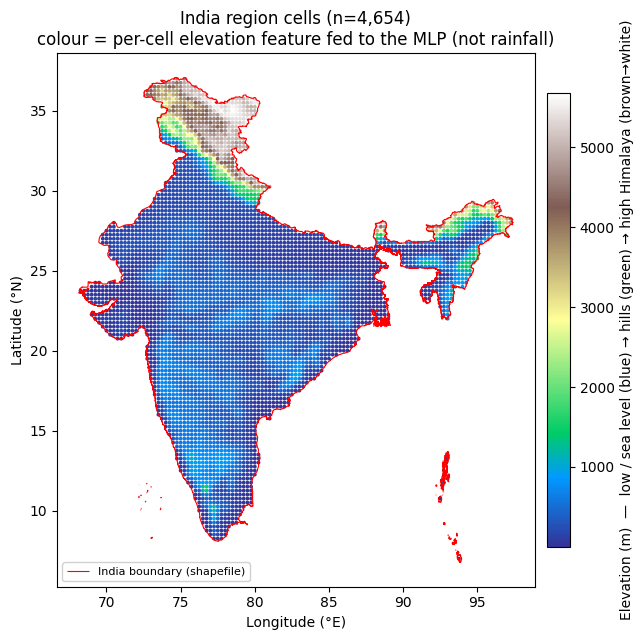

In [19]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5 — Master grid (IMD) + India shapefile mask + elevation        ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Master grid = IMD 0.25° grid (the observational truth / downscaling target).
imd_ds  = xr.open_dataset(IMD_MONTHLY)
reg_lats = np.sort(imd_ds["lat"].values)
reg_lons = np.sort(imd_ds["lon"].values)
nr_lat, nr_lon = len(reg_lats), len(reg_lons)
imd_ds.close()
print(f"Master grid (IMD): {nr_lat} × {nr_lon} | "
      f"lat {reg_lats[0]:.2f}→{reg_lats[-1]:.2f}  lon {reg_lons[0]:.2f}→{reg_lons[-1]:.2f}")

# India mask from the shapefile (NOT from data extent)
gdf = gpd.read_file(SHAPEFILE)
gdf = gdf.set_crs(epsg=4326) if gdf.crs is None else gdf.to_crs(epsg=4326)
region_geom = gdf.union_all() if hasattr(gdf, "union_all") else gdf.unary_union
lon_g, lat_g = np.meshgrid(reg_lons, reg_lats)
try:
    from shapely import contains_xy
    region_mask = contains_xy(region_geom, lon_g.ravel(), lat_g.ravel()).reshape(lon_g.shape)
except Exception:
    from shapely.vectorized import contains
    region_mask = contains(region_geom, lon_g.ravel(), lat_g.ravel()).reshape(lon_g.shape)
n_region = int(region_mask.sum())
assert n_region > 0, "0 cells inside India shapefile — check CRS/grid."
flat_idx = np.where(region_mask.ravel())[0]
ii_loc, jj_loc = np.unravel_index(flat_idx, (nr_lat, nr_lon))
print(f"India mask : {n_region:,} cells inside the shapefile")

# elevation interpolated onto the region cells
de = xr.open_dataset(ELEV_FILE)
e_lat = next(de[n].values for n in ["lat","latitude","LATITUDE","y"] if n in de.variables)
e_lon = next(de[n].values for n in ["lon","longitude","LONGITUDE","x"] if n in de.variables)
e_var = next((v for v in ["elevation","elev","z","Band1","srtm","SRTM","height","topo"]
              if v in de.data_vars), list(de.data_vars)[0])
elev = np.nan_to_num(de[e_var].values.astype("float32"), nan=0.0)
de.close()
if e_lat[0] > e_lat[-1]:
    e_lat = e_lat[::-1]; elev = elev[::-1, :]
interp_elev = RegularGridInterpolator((e_lat, e_lon), elev,
                                      method="linear", bounds_error=False, fill_value=0.0)
elev_reg = interp_elev(np.column_stack([reg_lats[ii_loc], reg_lons[jj_loc]])).astype("float32")

# static features per region cell: [lat, lon, elev]
STATIC_COLS = np.column_stack([reg_lats[ii_loc], reg_lons[jj_loc], elev_reg]).astype("float32")
print(f"Static features {STATIC_COLS.shape} [lat,lon,elev] | "
      f"elev {elev_reg.min():.0f}–{elev_reg.max():.0f} m")

# is the GCM monthly grid identical to the master grid? (fast path vs interp)
_gm = xr.open_dataset(GCM_MONTHLY)
gcm_lats = np.sort(_gm["lat"].values); gcm_lons = np.sort(_gm["lon"].values)
_gm.close()
GCM_ON_MASTER = (gcm_lats.shape == reg_lats.shape and gcm_lons.shape == reg_lons.shape
                 and np.allclose(gcm_lats, reg_lats, atol=1e-4)
                 and np.allclose(gcm_lons, reg_lons, atol=1e-4))
print("GCM grid matches master grid:", GCM_ON_MASTER,
      "" if GCM_ON_MASTER else "→ will interpolate GCM onto master grid")

fig, ax = plt.subplots(figsize=(7, 6.5))
sc = ax.scatter(reg_lons[jj_loc], reg_lats[ii_loc], s=3, c=elev_reg, cmap="terrain")
gdf.boundary.plot(ax=ax, color="red", lw=0.8, label="India boundary (shapefile)")
cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("Elevation (m)  —  low / sea level (blue) → hills (green) → "
             "high Himalaya (brown→white)")
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title(f"India region cells (n={n_region:,})\n"
             "colour = per-cell elevation feature fed to the MLP (not rainfall)")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

In [20]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 6 — Helpers: monthly loaders · features · MLP · QM · trainer     ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Load the two monthly datasets once into memory (they are small).
_GCM_MON = xr.open_dataset(GCM_MONTHLY).sortby("lat").sortby("lon")
_IMD_MON = xr.open_dataset(IMD_MONTHLY).sortby("lat").sortby("lon")
_GCM_TIME = pd.to_datetime(_GCM_MON["time"].values)
_IMD_TIME = pd.to_datetime(_IMD_MON["time"].values)
_gcm_lats = np.sort(_GCM_MON["lat"].values); _gcm_lons = np.sort(_GCM_MON["lon"].values)

def _gcm_map_to_region(map2d):
    """(nlat_gcm, nlon_gcm) → (n_region,) on the master grid."""
    if GCM_ON_MASTER:
        return map2d[ii_loc, jj_loc]
    f = RegularGridInterpolator((_gcm_lats, _gcm_lons), map2d,
                                method="linear", bounds_error=False, fill_value=np.nan)
    return f(np.column_stack([reg_lats[ii_loc], reg_lons[jj_loc]])).astype("float32")

def load_gcm_month(years, month):
    """Return (data[T,n_region], times) of GCM monthly values for given month/years."""
    sel = np.array([(t.year in set(years)) and (t.month == month) for t in _GCM_TIME])
    if not sel.any(): return None, None
    arr = _GCM_MON["pr"].values[sel]                         # (T, nlat, nlon)
    out = np.stack([_gcm_map_to_region(arr[k]) for k in range(arr.shape[0])])
    return out.astype("float32"), _GCM_TIME[sel]

def load_imd_month(years, month):
    """Return IMD monthly target (T, n_region) for given month/years."""
    sel = np.array([(t.year in set(years)) and (t.month == month) for t in _IMD_TIME])
    if not sel.any(): return None, None
    arr = _IMD_MON["pr"].values[sel]
    return arr[:, ii_loc, jj_loc].astype("float32"), _IMD_TIME[sel]

# ── feature builder: [gcm_monthly, lat, lon, elev] ──────────────────────
def build_X(gcm_vals):                                       # gcm_vals: (T, n_region)
    T = gcm_vals.shape[0]
    X = np.empty((T * n_region, N_FEATURES), dtype="float32")
    X[:, 0] = gcm_vals.ravel()
    X[:, 1] = np.tile(STATIC_COLS[:, 0], T)
    X[:, 2] = np.tile(STATIC_COLS[:, 1], T)
    X[:, 3] = np.tile(STATIC_COLS[:, 2], T)
    return X

# ── configurable MLP (output ≥ 0 via Softplus) ──────────────────────────
class MLPNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act = {"gelu": nn.GELU, "leaky_relu": nn.LeakyReLU, "relu": nn.ReLU}.get(
              cfg.get("activation", "relu"), nn.ReLU)
        layers, prev = [], N_FEATURES
        for h in cfg["hidden"]:
            layers.append(nn.Linear(prev, h))
            if cfg.get("batchnorm", True):
                layers.append(nn.BatchNorm1d(h))
            layers += [act(), nn.Dropout(cfg.get("dropout", 0.2))]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Softplus()]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

DEFAULT_CFG = {"hidden": [256, 128, 64], "dropout": 0.2, "lr": 1e-3,
               "weight_decay": 0.0, "batch_size": 8192, "activation": "relu",
               "batchnorm": True, "log_transform": True, "epochs": EPOCHS}

def load_cfg():
    for path, tag in [(FINAL_CFG, "final (Cell 8)"), (BEST_PARAMS, "Optuna best")]:
        if os.path.exists(path):
            with open(path) as f: c = json.load(f)
            c.setdefault("epochs", EPOCHS)
            print(f"✅ Using {tag} config: {c['hidden']} | lr={c['lr']:.2e} "
                  f"| drop={c['dropout']:.2f} | log={c['log_transform']} | ep={c['epochs']}")
            return c
    print("⚠ No saved config — using DEFAULT_CFG")
    return dict(DEFAULT_CFG)

# ── inference helpers (log transform + AMP aware) ───────────────────────
def _predict(model, X_sc, log, bs):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X_sc), bs):
            xb = torch.from_numpy(X_sc[i:i+bs]).to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                p = model(xb)
            out.append(p.float().cpu().numpy())
    p = np.concatenate(out)
    return np.clip(np.expm1(p) if log else p, 0, None)

def _rmse(model, X_sc, y, log, bs):
    return float(np.sqrt(mean_squared_error(y, _predict(model, X_sc, log, bs))))

# ── shared trainer (Optuna + final pipeline) ────────────────────────────
def train_model(cfg, X_tr, y_tr, X_val=None, y_val=None,
                trial=None, epochs=None, patience=15):
    import optuna
    epochs = epochs or cfg.get("epochs", EPOCHS)
    log = cfg.get("log_transform", True); bs = cfg["batch_size"]
    model = MLPNet(cfg).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                             weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.MSELoss()
    gscale = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    y_in = np.log1p(y_tr).astype("float32") if log else y_tr.astype("float32")
    # drop_last only if it still leaves a full batch (avoids BN-on-size-1 crash)
    drop_last = (len(X_tr) // bs) >= 2
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_in)),
                        batch_size=bs, shuffle=True, drop_last=drop_last,
                        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
                        persistent_workers=USE_AMP)
    best_val, best_state, bad = np.inf, None, 0
    hist = {"train_loss": [], "val_rmse": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            if Xb.shape[0] == 1:        # BatchNorm needs >1 sample
                continue
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gscale.scale(loss).backward(); gscale.step(opt); gscale.update()
            run += loss.item()
        sched.step()
        hist["train_loss"].append(run / max(1, len(loader)))
        if X_val is not None:
            vr = _rmse(model, X_val, y_val, log, bs)
            hist["val_rmse"].append(vr)
            if trial is not None:
                trial.report(vr, ep)
                if trial.should_prune():
                    raise optuna.TrialPruned()
            if vr < best_val - 1e-4:
                best_val = vr; bad = 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
                if bad >= patience: break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, (best_val if np.isfinite(best_val) else hist["train_loss"][-1]), hist

# ── Quantile-mapping transfer functions (per-cell, per-month) ───────────
def fit_qmap(obs_2d, mod_2d):
    obs = np.where(np.isnan(obs_2d), np.nanmedian(obs_2d, axis=0), obs_2d)
    mod = np.where(np.isnan(mod_2d), np.nanmedian(mod_2d, axis=0), mod_2d)
    return (np.quantile(obs, Q_LEVELS, axis=0).T.astype("float32"),
            np.quantile(mod, Q_LEVELS, axis=0).T.astype("float32"))

def apply_qmap(mod_2d, obs_q, mod_q):
    bc = np.full_like(mod_2d, np.nan)
    for k in range(n_region):
        vals = mod_2d[:, k]; nm = np.isnan(vals)
        if np.any(~nm) and not np.isnan(mod_q[k, 0]):
            _, uid = np.unique(mod_q[k], return_index=True)
            bc[~nm, k] = np.clip(np.interp(vals[~nm], mod_q[k, uid], obs_q[k, uid]), 0, None)
    return bc

# ── sanity check on January ─────────────────────────────────────────────
_g, _ = load_gcm_month(TRAIN_YEARS, 1)
_c, _ = load_imd_month(TRAIN_YEARS, 1)
print(f"✅ Helpers ready (region {n_region:,} cells).  Jan sanity:")
print(f"   GCM monthly {_g.shape}  {np.nanmin(_g):.3f}–{np.nanmax(_g):.3f}")
print(f"   IMD monthly {_c.shape}  {np.nanmin(_c):.3f}–{np.nanmax(_c):.3f}")

✅ Helpers ready (region 4,654 cells).  Jan sanity:
   GCM monthly (25, 4654)  0.000–15.932
   IMD monthly (25, 4654)  0.000–38.354


[I 2026-06-13 19:24:45,578] Using an existing study with name 'india_pr_monthly' instead of creating a new one.


Jul: train=97,251 val=18,524 obs std=8.06
Jan: train=97,251 val=18,524 obs std=0.81
Completed trials: 7 | running 33 more


  0%|          | 0/33 [00:00<?, ?it/s]

[I 2026-06-13 19:25:06,743] Trial 15 finished with value: 0.8229166983212278 and parameters: {'n_layers': 4, 'u0_512': 128, 'u1_128': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.10964472320430323, 'lr': 0.0012231822374746577, 'weight_decay': 4.6343808617582615e-05, 'batch_size': 2048, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 15 with value: 0.8229166983212278.
[I 2026-06-13 19:25:11,516] Trial 16 pruned. 
[I 2026-06-13 19:25:57,883] Trial 17 finished with value: 0.8343053894695847 and parameters: {'n_layers': 4, 'u0_512': 128, 'u1_128': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.10979398931299233, 'lr': 0.0006577476460079474, 'weight_decay': 4.387371055382265e-05, 'batch_size': 2048, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 15 with value: 0.8229166983212278.
[I 2026-06-13 19:26:02,879] Trial 18 pruned. 


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e275e987380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


...

[I 2026-06-13 19:27:03,445] Trial 23 finished with value: 0.8277006639725001 and parameters: {'n_layers': 4, 'u0_512': 128, 'u1_128': 128, 'u2_128': 64, 'u3_64': 64, 'dropout': 0.07264721332596097, 'lr': 0.0013628548846612949, 'weight_decay': 1.12486942639232e-06, 'batch_size': 4096, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 15 with value: 0.8229166983212278.
[I 2026-06-13 19:27:34,568] Trial 24 finished with value: 0.8215131374808364 and parameters: {'n_layers': 4, 'u0_512': 128, 'u1_128': 128, 'u2_128': 64, 'u3_64': 64, 'dropout': 0.069050486470593, 'lr': 0.0013620789137456153, 'weight_decay': 1.2328017498639434e-05, 'batch_size': 4096, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 24 with value: 0.8215131374808364.
[I 2026-06-13 19:27:39,458] Trial 25 pruned. 
[I 2026-06-13 19:27:44,736] Trial 26 pruned. 
[I 2026-06-13 19:28:10,694] Trial 27 finished with value: 0.8109964538481028 and parameters: {'n_layers': 4, '

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e275e987380><function _MultiProcessingDataLoaderIter.__del__ at 0x7e275e987380>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():
 if w.is_alive():  
        ^^   ^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^

  File "/usr/lib/python

[I 2026-06-13 19:29:49,342] Trial 31 finished with value: 0.863384426001163 and parameters: {'n_layers': 3, 'u0_512': 512, 'u1_512': 512, 'u2_512': 128, 'dropout': 0.045704140014196135, 'lr': 0.0035096171213019603, 'weight_decay': 1.245887113997242e-05, 'batch_size': 2048, 'activation': 'relu', 'batchnorm': True, 'log_transform': False}. Best is trial 27 with value: 0.8109964538481028.
[I 2026-06-13 19:30:20,395] Trial 32 finished with value: 0.8152552252627416 and parameters: {'n_layers': 4, 'u0_512': 64, 'u1_64': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.06751323565731081, 'lr': 0.00302443862060859, 'weight_decay': 2.1249625597293515e-06, 'batch_size': 4096, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 27 with value: 0.8109964538481028.
[I 2026-06-13 19:30:47,445] Trial 33 finished with value: 0.8135252027783331 and parameters: {'n_layers': 4, 'u0_512': 64, 'u1_64': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.06791371764420512, 'lr': 0.00353946315616

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e275e987380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a child process'
     ^      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


[I 2026-06-13 19:33:39,111] Trial 43 finished with value: 0.8044187013444959 and parameters: {'n_layers': 4, 'u0_512': 64, 'u1_64': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.0005800047171013456, 'lr': 0.002809021450103388, 'weight_decay': 6.946828379337459e-08, 'batch_size': 2048, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 43 with value: 0.8044187013444959.
[I 2026-06-13 19:34:12,753] Trial 44 finished with value: 0.8161458201543978 and parameters: {'n_layers': 4, 'u0_512': 64, 'u1_64': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.008840723760406547, 'lr': 0.0029119879158323674, 'weight_decay': 4.37079239642036e-08, 'batch_size': 2048, 'activation': 'relu', 'batchnorm': True, 'log_transform': True}. Best is trial 43 with value: 0.8044187013444959.
[I 2026-06-13 19:34:49,733] Trial 45 finished with value: 0.8217581762972967 and parameters: {'n_layers': 4, 'u0_512': 64, 'u1_64': 64, 'u2_64': 64, 'u3_64': 64, 'dropout': 0.04166186907715659, 'lr': 0.00382

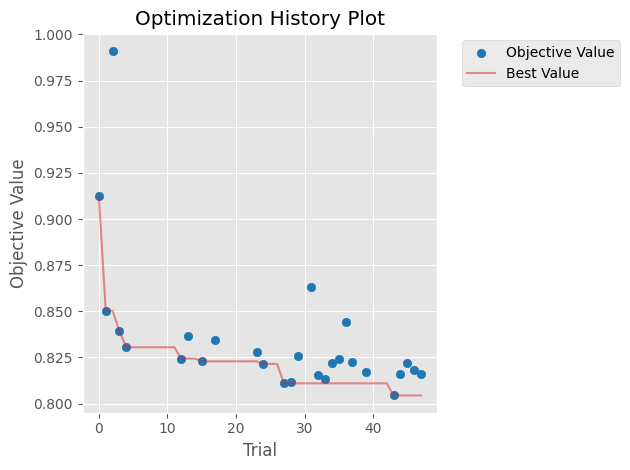

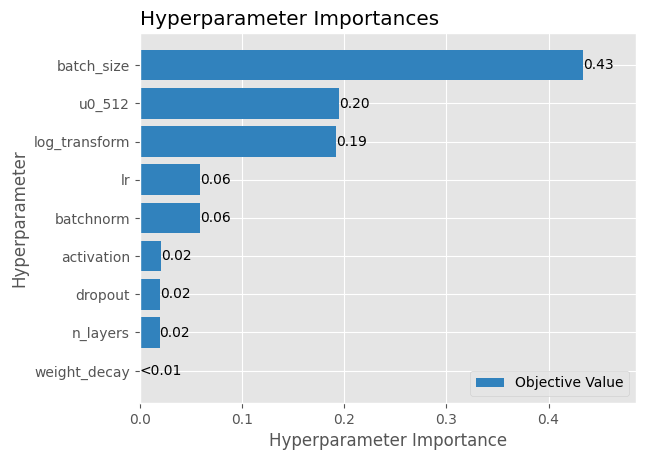

In [21]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 7 — OPTUNA hyper-parameter search (resumable)                    ║
# ║  Every finished trial persists to optuna_study.db instantly.          ║
# ╚══════════════════════════════════════════════════════════════════════╝
import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner

TUNE_MONTHS = [7, 1]        # July (monsoon) + January (dry) — span the regimes
N_TRIALS    = 40
TUNE_EPOCHS = 40
VAL_YEARS   = 4             # last N train years → validation

# resume from a previously-uploaded db if present
import shutil
_prev = os.path.join(BASE, "optuna_study.db")
if os.path.exists(_prev) and not os.path.exists(OPTUNA_DB):
    shutil.copy(_prev, OPTUNA_DB); print("Resuming study from uploaded optuna_study.db")

# preload + scale both tuning months, split by YEAR
cut = TRAIN_END - VAL_YEARS
month_data = {}
for m in TUNE_MONTHS:
    g, tg = load_gcm_month(TRAIN_YEARS, m)
    c, tc = load_imd_month(TRAIN_YEARS, m)
    n = min(len(g), len(c)); g, c = g[:n], c[:n]
    X = build_X(g); y = c.reshape(-1)
    yr = np.repeat([t.year for t in tg[:n]], n_region)
    fin = np.isfinite(X).all(1) & np.isfinite(y) & (y >= 0)
    tr, va = fin & (yr <= cut), fin & (yr > cut)
    sc = StandardScaler().fit(X[tr])
    month_data[m] = dict(Xtr=sc.transform(X[tr]).astype("float32"), ytr=y[tr],
                         Xva=sc.transform(X[va]).astype("float32"), yva=y[va],
                         ystd=float(np.nanstd(y[va]) + 1e-6))
    print(f"{MONTH_NAMES[m-1]}: train={int(tr.sum()):,} val={int(va.sum()):,} "
          f"obs std={month_data[m]['ystd']:.2f}")

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    hidden, prev = [], 512
    for i in range(n_layers):
        choices = [c for c in [512, 256, 128, 64] if c <= prev]
        h = trial.suggest_categorical(f"u{i}_{prev}", choices)
        hidden.append(h); prev = h
    cfg = {"hidden": hidden,
           "dropout":      trial.suggest_float("dropout", 0.0, 0.4),
           "lr":           trial.suggest_float("lr", 1e-4, 5e-3, log=True),
           "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
           "batch_size":   trial.suggest_categorical("batch_size", [2048, 4096, 8192, 16384]),
           "activation":   trial.suggest_categorical("activation", ["relu","gelu","leaky_relu"]),
           "batchnorm":    trial.suggest_categorical("batchnorm", [True, False]),
           "log_transform":trial.suggest_categorical("log_transform", [True, False])}
    score = 0.0
    for k, m in enumerate(TUNE_MONTHS):
        d = month_data[m]
        _, rmse, _ = train_model(cfg, d["Xtr"], d["ytr"], d["Xva"], d["yva"],
                                 trial=trial if k == 0 else None,
                                 epochs=TUNE_EPOCHS, patience=8)
        trial.set_user_attr(f"rmse_{MONTH_NAMES[m-1]}", float(rmse))
        score += (rmse / d["ystd"]) / len(TUNE_MONTHS)
    return score

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED),
                            pruner=MedianPruner(n_warmup_steps=6),
                            study_name="india_pr_monthly",
                            storage=f"sqlite:///{OPTUNA_DB}", load_if_exists=True)
done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f"Completed trials: {done} | running {max(N_TRIALS-done,0)} more")
if N_TRIALS - done > 0:
    study.optimize(objective, n_trials=N_TRIALS - done, show_progress_bar=True)

print(f"\nBest relative RMSE: {study.best_value:.4f}  (<1 beats climatological mean)")
for m in TUNE_MONTHS:
    print(f"  {MONTH_NAMES[m-1]} RMSE: "
          f"{study.best_trial.user_attrs.get('rmse_'+MONTH_NAMES[m-1]):.3f} mm/day")
print("Best params:", study.best_params)

# rebuild + save best config
bp = study.best_params; hidden, prev = [], 512
for i in range(bp["n_layers"]):
    hidden.append(bp[f"u{i}_{prev}"]); prev = hidden[-1]
BEST = {"hidden": hidden, "dropout": float(bp["dropout"]), "lr": float(bp["lr"]),
        "weight_decay": float(bp["weight_decay"]), "batch_size": int(bp["batch_size"]),
        "activation": bp["activation"], "batchnorm": bool(bp["batchnorm"]),
        "log_transform": bool(bp["log_transform"]), "epochs": EPOCHS,
        "tuned_on_months": TUNE_MONTHS, "best_score": float(study.best_value)}
with open(BEST_PARAMS, "w") as f: json.dump(BEST, f, indent=2)

rows = []
for t in study.trials:
    r = {"trial": t.number, "state": str(t.state), "value": t.value}
    r.update(t.params); r.update(t.user_attrs); rows.append(r)
pd.DataFrame(rows).to_csv(f"{LOG_DIR}/optuna_trials_full.csv", index=False)
print(f"✅ saved best → {BEST_PARAMS}\n✅ saved trials → {LOG_DIR}/optuna_trials_full.csv")
try:
    from optuna.visualization.matplotlib import (plot_optimization_history,
                                                  plot_param_importances)
    plot_optimization_history(study).figure.savefig(f"{LOG_DIR}/optuna_history.png",
                                                     dpi=150, bbox_inches="tight")
    plot_param_importances(study).figure.savefig(f"{LOG_DIR}/optuna_importance.png",
                                                  dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Plot skipped:", e)
for m in TUNE_MONTHS: month_data[m].clear()

In [22]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 8 — MANUAL override after Optuna (tweak lr / epochs / etc.)      ║
# ║  Edit OVERRIDES below, run this cell → writes final_config.json,       ║
# ║  which Cell 9 (training) will pick up automatically.                  ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Start from Optuna's best (if available), else the default config.
base = dict(DEFAULT_CFG)
if os.path.exists(BEST_PARAMS):
    with open(BEST_PARAMS) as f: base.update(json.load(f))

# ── EDIT THESE after looking at the Optuna results ───────────────────────
OVERRIDES = {
    # "lr": 5e-4,                 # ← change learning rate
    # "epochs": 250,              # ← change number of epochs
    # "batch_size": 8192,
    # "dropout": 0.15,
    # "hidden": [512, 256, 128, 64],
    # "log_transform": True,
}
base.update({k: v for k, v in OVERRIDES.items() if v is not None})
base.setdefault("epochs", EPOCHS)

with open(FINAL_CFG, "w") as f: json.dump(base, f, indent=2)
print("Final config saved → final_config.json")
for k in ["hidden","lr","epochs","batch_size","dropout","weight_decay",
          "activation","batchnorm","log_transform"]:
    print(f"  {k:<14}: {base.get(k)}")

Final config saved → final_config.json
  hidden        : [64, 64, 64, 64]
  lr            : 0.002809021450103388
  epochs        : 300
  batch_size    : 2048
  dropout       : 0.0005800047171013456
  weight_decay  : 6.946828379337459e-08
  activation    : relu
  batchnorm     : True
  log_transform : True


In [23]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 9 — TRAIN 12 monthly MLPs (saves models, scalers, epoch logs)    ║
# ║  Re-runnable: months already trained (model + QM present) are skipped. ║
# ╚══════════════════════════════════════════════════════════════════════╝
CFG = load_cfg(); LOG = CFG["log_transform"]; BS = CFG["batch_size"]
VAL_YEARS_FIN, PATIENCE = 3, 15
cut_fin = TRAIN_END - VAL_YEARS_FIN

# resume-safe QM store
tf_store = {}
if os.path.exists(QM_TF_PATH):
    with np.load(QM_TF_PATH) as z:
        tf_store = {k: z[k] for k in z.files}
    print(f"Loaded {len(tf_store)//2} existing QM month(s) from disk")

train_summary, epoch_metrics = {}, {}
print("\n" + "="*60 + "\n  TRAINING — 12 monthly MLPs\n" + "="*60)
for month in range(1, 13):
    mname, mstr = MONTH_NAMES[month-1], f"m{month:02d}"
    mp = os.path.join(MODEL_DIR, f"mlp_{mstr}.pth")
    have_qm = (f"{mstr}_obs_q" in tf_store) and (f"{mstr}_mod_q" in tf_store)
    if os.path.exists(mp) and have_qm:
        print(f"  ✓ {mname} already trained + QM present — skipping"); continue

    print(f"\n{'─'*55}\n  [{month:02d}/12] {mname}  {pd.Timestamp.now():%H:%M:%S}\n{'─'*55}", flush=True)
    g, tg = load_gcm_month(TRAIN_YEARS, month)
    c, tc = load_imd_month(TRAIN_YEARS, month)
    if g is None or c is None:
        print("  ✗ missing data"); continue
    n = min(len(g), len(c)); g, c, tg = g[:n], c[:n], tg[:n]

    X_all = build_X(g); y_all = c.reshape(-1)
    yrlab = np.repeat([t.year for t in tg], n_region)
    fin   = np.isfinite(X_all).all(1) & np.isfinite(y_all) & (y_all >= 0)
    fit_m = fin & (yrlab <= cut_fin)
    val_m = fin & (yrlab >  cut_fin)
    print(f"  fit={int(fit_m.sum()):,}  val={int(val_m.sum()):,} "
          f"(val yrs {cut_fin+1}-{TRAIN_END})", flush=True)

    scaler = StandardScaler().fit(X_all[fit_m])
    joblib.dump(scaler, os.path.join(SCALER_DIR, f"scaler_{mstr}.joblib"))
    Xfit = scaler.transform(X_all[fit_m]).astype("float32"); yfit = y_all[fit_m]
    Xval = scaler.transform(X_all[val_m]).astype("float32"); yval = y_all[val_m]

    model, best_val, hist = train_model(CFG, Xfit, yfit, Xval, yval,
                                        epochs=CFG["epochs"], patience=PATIENCE)
    torch.save(model.state_dict(), mp)
    epoch_metrics[month] = hist
    print(f"  best val RMSE={best_val:.4f}  (epochs run={len(hist['train_loss'])})", flush=True)

    # train + test skill
    Xtr_sc = scaler.transform(X_all[fin]).astype("float32")
    p_tr   = _predict(model, Xtr_sc, LOG, BS)
    rmse_tr = float(np.sqrt(mean_squared_error(y_all[fin], p_tr)))
    r2_tr   = float(r2_score(y_all[fin], p_tr))
    gte, _ = load_gcm_month(TEST_YEARS, month)
    cte, _ = load_imd_month(TEST_YEARS, month)
    rmse_te = r2_te = np.nan
    if gte is not None and cte is not None:
        nte = min(len(gte), len(cte))
        Xte = build_X(gte[:nte]); yte = cte[:nte].reshape(-1)
        vte = np.isfinite(Xte).all(1) & np.isfinite(yte) & (yte >= 0)
        p_te = _predict(model, scaler.transform(Xte[vte]).astype("float32"), LOG, BS)
        rmse_te = float(np.sqrt(mean_squared_error(yte[vte], p_te)))
        r2_te   = float(r2_score(yte[vte], p_te))
    train_summary[month] = (rmse_tr, r2_tr, rmse_te, r2_te)
    print(f"  TR RMSE={rmse_tr:.4f} R²={r2_tr:.4f} | TE RMSE={rmse_te:.4f} R²={r2_te:.4f}", flush=True)

    # fit QM on full-train predictions vs obs (per cell, this month)
    p_grid = np.full(len(y_all), np.nan, "float32"); p_grid[fin] = p_tr
    p_grid = p_grid.reshape(n, n_region)
    obs_q, mod_q = fit_qmap(c, p_grid)
    tf_store[f"{mstr}_obs_q"] = obs_q; tf_store[f"{mstr}_mod_q"] = mod_q
    np.savez_compressed(QM_TF_PATH, **tf_store)

    # save epoch log for this month
    vr = hist["val_rmse"] + [np.nan]*(len(hist["train_loss"]) - len(hist["val_rmse"]))
    pd.DataFrame({"epoch": range(1, len(hist["train_loss"])+1),
                  "train_loss": hist["train_loss"], "val_rmse": vr}
                 ).to_csv(f"{LOG_DIR}/epoch_metrics_{mstr}.csv", index=False)
    print("  ✓ QM fitted + epoch log saved", flush=True)
    del X_all, y_all, Xfit, Xval, Xtr_sc
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# persist the train/test summary
if train_summary:
    pd.DataFrame([{"month": MONTH_NAMES[m-1], "train_rmse": v[0], "train_r2": v[1],
                   "test_rmse": v[2], "test_r2": v[3]} for m, v in sorted(train_summary.items())]
                 ).to_csv(f"{LOG_DIR}/train_test_summary.csv", index=False)
print("\n✅ All models + QM TFs saved.")
print(f"\n  {'Month':<6}{'TR_RMSE':>10}{'TR_R²':>9}{'TE_RMSE':>10}{'TE_R²':>9}\n  " + "─"*44)
for m in range(1, 13):
    if m in train_summary:
        a,b,c2,d = train_summary[m]
        print(f"  {MONTH_NAMES[m-1]:<6}{a:>10.4f}{b:>9.4f}{c2:>10.4f}{d:>9.4f}")

✅ Using final (Cell 8) config: [64, 64, 64, 64] | lr=2.81e-03 | drop=0.00 | log=True | ep=300

  TRAINING — 12 monthly MLPs

───────────────────────────────────────────────────────
  [01/12] Jan  19:35:49
───────────────────────────────────────────────────────
  fit=101,882  val=13,893 (val yrs 2002-2004)
  best val RMSE=0.7303  (epochs run=17)
  TR RMSE=0.9017 R²=0.3714 | TE RMSE=1.1763 R²=0.2429
  ✓ QM fitted + epoch log saved

───────────────────────────────────────────────────────
  [02/12] Feb  19:36:02
───────────────────────────────────────────────────────
  fit=101,882  val=13,893 (val yrs 2002-2004)
  best val RMSE=1.1904  (epochs run=28)
  TR RMSE=1.1829 R²=0.4788 | TE RMSE=1.4960 R²=0.3477
  ✓ QM fitted + epoch log saved

───────────────────────────────────────────────────────
  [03/12] Mar  19:36:24
───────────────────────────────────────────────────────
  fit=101,882  val=13,893 (val yrs 2002-2004)
  best val RMSE=1.6538  (epochs run=16)
  TR RMSE=1.6872 R²=0.4309 | TE RMS

In [24]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 10 — INFERENCE → downscaled monthly NetCDF (train + test)        ║
# ╚══════════════════════════════════════════════════════════════════════╝
CFG = load_cfg(); LOG = CFG["log_transform"]; BS = CFG["batch_size"]

def infer_period(years, out_file, label):
    maps, times = [], []
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        mp = os.path.join(MODEL_DIR, f"mlp_{mstr}.pth")
        sp = os.path.join(SCALER_DIR, f"scaler_{mstr}.joblib")
        if not os.path.exists(mp): continue
        model = MLPNet(CFG).to(DEVICE)
        model.load_state_dict(torch.load(mp, map_location=DEVICE)); model.eval()
        sc = joblib.load(sp)
        g, tg = load_gcm_month(years, month)
        if g is None: continue
        p = _predict(model, sc.transform(build_X(g)).astype("float32"),
                     LOG, BS).reshape(len(g), n_region)
        for di, t in enumerate(tg):
            grid = np.full((nr_lat, nr_lon), np.nan, "float32")
            grid[ii_loc, jj_loc] = p[di]
            maps.append(grid); times.append(pd.Timestamp(t))
        print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)
        del model, sc, g
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    print()
    arr = np.stack(maps); t = pd.to_datetime(times); idx = np.argsort(t)
    xr.Dataset({"pr": (["time","lat","lon"], arr[idx],
                       {"units":"mm/day","long_name":f"MLP downscaled monthly {label}"})},
               coords={"time": t[idx], "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB) → {out_file}")

print("="*60 + "\n  INFERENCE (downscaling)\n" + "="*60)
infer_period(TRAIN_YEARS, MLP_MON_TR, "train")
infer_period(TEST_YEARS,  MLP_MON_TE, "test")

✅ Using final (Cell 8) config: [64, 64, 64, 64] | lr=2.81e-03 | drop=0.00 | log=True | ep=300
  INFERENCE (downscaling)
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✅ train: (300, 129, 135)  (4.3 MB) → /kaggle/working/india_monthly_downscaling/mlp_monthly_train.nc
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✅ test: (120, 129, 135)  (1.9 MB) → /kaggle/working/india_monthly_downscaling/mlp_monthly_test.nc


In [25]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 11 — QM BIAS CORRECTION → bias-corrected monthly NetCDF          ║
# ║  QM transfer functions were fitted on the training period in Cell 9.   ║
# ╚══════════════════════════════════════════════════════════════════════╝
# (re)load QM TFs from disk so this cell runs standalone
tf_store = {}
with np.load(QM_TF_PATH) as z:
    tf_store = {k: z[k] for k in z.files}
print(f"Loaded {len(tf_store)//2} QM month(s) from disk")

def bc_period(mlp_nc, out_file, label):
    ds = xr.open_dataset(mlp_nc); maps, times = [], []
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        obs_q = tf_store.get(f"{mstr}_obs_q"); mod_q = tf_store.get(f"{mstr}_mod_q")
        if obs_q is None: continue
        da = ds["pr"].sel(time=ds["pr"].time.dt.month == month)
        if len(da.time) == 0: continue
        bc = apply_qmap(da.values[:, ii_loc, jj_loc], obs_q, mod_q)
        for di, t in enumerate(pd.to_datetime(da.time.values)):
            grid = np.full((nr_lat, nr_lon), np.nan, "float32")
            grid[ii_loc, jj_loc] = bc[di]
            maps.append(grid); times.append(t)
        print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)
    print(); ds.close()
    arr = np.stack(maps); t = pd.to_datetime(times); idx = np.argsort(t)
    xr.Dataset({"pr": (["time","lat","lon"], arr[idx],
                       {"units":"mm/day","long_name":f"QM bias-corrected monthly {label}"})},
               coords={"time": t[idx], "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB) → {out_file}")

print("="*60 + "\n  QM BIAS CORRECTION\n" + "="*60)
bc_period(MLP_MON_TR, BC_MON_TR, "train")
bc_period(MLP_MON_TE, BC_MON_TE, "test")
print("\n✅ Bias-corrected monthly outputs ready. Next: temporal disaggregation (Cell 12).")

Loaded 12 QM month(s) from disk
  QM BIAS CORRECTION
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✅ train: (300, 129, 135)  (4.4 MB) → /kaggle/working/india_monthly_downscaling/bc_monthly_train.nc
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✅ test: (120, 129, 135)  (1.8 MB) → /kaggle/working/india_monthly_downscaling/bc_monthly_test.nc

✅ Bias-corrected monthly outputs ready. Next: temporal disaggregation (Cell 12).


In [26]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 12 — TEMPORAL DISAGGREGATION  (v5c)                              ║
# ║  Change Factor + GCM-anomaly analog-month selection (monthly → daily). ║
# ║  Method: for each (year, month) of the BC monthly field —             ║
# ║   1) pick the training year whose GCM India-mean anomaly best matches  ║
# ║      this target's anomaly (random among the top-3),                  ║
# ║   2) take that analog year's IMD daily pattern for the month,         ║
# ║   3) scale it by CF = BC_monthly / OBS_climatology(month).            ║
# ║  → daily pattern from a physically-similar year, monthly mean kept.    ║
# ╚══════════════════════════════════════════════════════════════════════╝
import random, calendar
random.seed(SEED)

DAILY_TR   = f"{OUT_DIR}/daily_train.nc"
DAILY_TE   = f"{OUT_DIR}/daily_test.nc"
HIST_YEARS = list(TRAIN_YEARS)
india_idx  = (ii_loc, jj_loc)                      # India cells on the master grid

# ── OBS (IMD) monthly climatology from the training period (per-month map) ──
print("Precomputing OBS climatology (training period)…")
_imd = xr.open_dataset(IMD_MONTHLY)
imd_obs_climatology = {}
for m in range(1, 13):
    sub = _imd["pr"].sel(time=_imd["pr"].time.dt.month == m)
    sub = sub.sel(time=sub.time.dt.year.isin(HIST_YEARS))
    imd_obs_climatology[m] = sub.mean("time", skipna=True).values.astype("float32")
_imd.close()
print("  ✓ 12 monthly climatology maps")

# ── GCM climatology + anomalies (India-mean) from the training period ──────
print("Precomputing GCM climatology + anomalies…")
gcm_climatology, gcm_anomalies = {}, {}
for m in range(1, 13):
    g, tg = load_gcm_month(HIST_YEARS, m)
    if g is None:
        gcm_climatology[m] = 0.0; continue
    ymean = np.nanmean(g, axis=1)                  # India-mean per year
    gcm_climatology[m] = float(np.nanmean(ymean))
    for t, v in zip(tg, ymean):
        gcm_anomalies[(t.year, m)] = float(v - gcm_climatology[m])
print(f"  ✓ anomalies cached: {len(gcm_anomalies)}")

# ── IMD daily loader, aligned to the master grid ───────────────────────────
def load_imd_daily(yr):
    ds = xr.open_dataset(IMD_FILES[yr])
    da = ds[IMD_VAR]
    ren = {}
    if IMD_LAT  != "lat":  ren[IMD_LAT]  = "lat"
    if IMD_LON  != "lon":  ren[IMD_LON]  = "lon"
    if IMD_TIME != "time": ren[IMD_TIME] = "time"
    da = da.rename(ren).sortby("lat").sortby("lon")
    arr = _clean_fill(da.values)                   # fills → NaN  (from Cell 3)
    t   = pd.to_datetime(da["time"].values)
    ds.close()
    return arr.astype("float32"), t

# ── analog-year selection by GCM anomaly ───────────────────────────────────
def find_analog(bc_map, month, top_n=3):
    bc_india = float(np.nanmean(np.nan_to_num(bc_map, nan=0.0)[region_mask]))
    target   = bc_india - gcm_climatology.get(month, 0.0)
    scores   = {y: abs(gcm_anomalies[(y, month)] - target)
                for y in HIST_YEARS if (y, month) in gcm_anomalies}
    if not scores:
        return random.choice(HIST_YEARS)
    return random.choice(sorted(scores, key=scores.get)[:top_n])

# ── v5c disaggregation for a single (year, month) ──────────────────────────
def disaggregate_v5c(bc_map, yr, month, is_future=False):
    # For genuine future SSP years (no obs) use is_future=True → random analog.
    ref_yr = random.choice(HIST_YEARS) if is_future else find_analog(bc_map, month)
    if ref_yr not in IMD_FILES:
        return None, None
    rf, t = load_imd_daily(ref_yr)
    if rf.shape[1:] != (nr_lat, nr_lon):           # grid must match master grid
        return None, None
    sel = (t.month == month)
    if sel.sum() == 0:
        return None, None

    imd_d    = np.nan_to_num(rf[sel], nan=0.0)
    bc_clean = np.nan_to_num(bc_map, nan=0.0)
    obs_clim = imd_obs_climatology[month]

    # Change Factor  CF = BC_monthly / OBS_climatology(month)  (clipped 0–10)
    cf    = np.zeros_like(obs_clim)
    valid = obs_clim > 0.0
    cf[valid] = bc_clean[valid] / obs_clim[valid]
    cf = np.clip(cf, 0, 10)

    daily = np.zeros_like(imd_d)
    if valid.any():                                 # clim wet → scale daily pattern
        daily[:, valid] = imd_d[:, valid] * cf[np.newaxis, valid]
    dry_clim_wet_bc = (~valid) & (bc_clean > 0)     # clim dry but BC wet → spread
    if dry_clim_wet_bc.any():
        daily[:, dry_clim_wet_bc] = bc_clean[dry_clim_wet_bc][np.newaxis, :]
    # (both dry → stays zero)

    # align to the TARGET year's calendar (avoids Feb leap/non-leap spillover)
    n_use = min(daily.shape[0], calendar.monthrange(yr, month)[1])
    daily = daily[:n_use]
    dates = pd.date_range(f"{yr}-{month:02d}-01", periods=n_use, freq="D")
    return np.clip(daily, 0, None).astype("float32"), dates

# ── quick sanity check: does the monthly mean survive disaggregation? ──────
sample_yr = HIST_YEARS[len(HIST_YEARS) // 2]
print(f"\nSanity check (year {sample_yr}):")
print(f"  {'Month':<8}{'BC_mean':>10}{'Out_mean':>10}{'Diff%':>8}{'Analog':>8}")
_dbc = xr.open_dataset(BC_MON_TR)
for m in [1, 4, 7, 10]:
    da = _dbc["pr"].sel(time=_dbc["pr"].time.dt.year == sample_yr)
    da = da.sel(time=da.time.dt.month == m)
    if len(da.time) == 0: continue
    bcm = da.values[0]
    an  = find_analog(bcm, m)
    d, _ = disaggregate_v5c(bcm, sample_yr, m)
    if d is None: continue
    bmean = float(np.nanmean(bcm[region_mask]))
    omean = float(np.nanmean(d[:, ii_loc, jj_loc]))
    pct   = abs(bmean - omean) / (bmean + 1e-6) * 100
    print(f"  {MONTH_NAMES[m-1]:<8}{bmean:>10.4f}{omean:>10.4f}{pct:>7.2f}%{an:>8}")
_dbc.close()

# ── run full disaggregation for train + test ───────────────────────────────
def run_disagg(bc_file, years, out_file, label, is_future=False):
    ds = xr.open_dataset(bc_file)
    maps, times = [], []
    for yr in years:
        for m in range(1, 13):
            da = ds["pr"].sel(time=ds["pr"].time.dt.year == yr)
            da = da.sel(time=da.time.dt.month == m)
            if len(da.time) == 0: continue
            d, t = disaggregate_v5c(da.values[0], yr, m, is_future)
            if d is None: continue
            maps.append(d); times.extend(pd.to_datetime(t).tolist())
        print(f"  {yr} ✓", end="  ", flush=True)
        if yr % 5 == 0: print()
    ds.close(); print()
    if not maps:
        print(f"  ✗ {label}: nothing produced"); return
    arr = np.concatenate(maps); tt = pd.to_datetime(times); idx = np.argsort(tt)
    xr.Dataset({"pr": (["time","lat","lon"], arr[idx],
                       {"units":"mm/day","long_name":f"Downscaled daily v5c {label}"})},
               coords={"time": tt[idx], "lat": reg_lats, "lon": reg_lons}
              ).to_netcdf(out_file, encoding={"pr":{"zlib":True,"complevel":4,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape}  ({os.path.getsize(out_file)/1e6:.1f} MB) → {out_file}")

print("\n" + "="*55 + "\n  TEMPORAL DISAGGREGATION (v5c)\n" + "="*55)
run_disagg(BC_MON_TR, TRAIN_YEARS, DAILY_TR, "train", is_future=False)
run_disagg(BC_MON_TE, TEST_YEARS,  DAILY_TE, "test",  is_future=False)
print("\n✓ Daily 0.25° outputs ready:")
print(f"   {DAILY_TR}\n   {DAILY_TE}")
print("Next: evaluation (Cell 13) — you'll provide the metrics/scales.")

Precomputing OBS climatology (training period)…
  ✓ 12 monthly climatology maps
Precomputing GCM climatology + anomalies…
  ✓ anomalies cached: 300

Sanity check (year 1992):
  Month      BC_mean  Out_mean   Diff%  Analog
  Jan         0.5518    0.6097  10.49%    1981
  Apr         0.9218    1.3228  43.49%    1997
  Jul         9.3116    7.5521  18.90%    1997
  Oct         2.2055    1.4695  33.37%    1980

  TEMPORAL DISAGGREGATION (v5c)
  1980 ✓  
  1981 ✓    1982 ✓    1983 ✓    1984 ✓    1985 ✓  
  1986 ✓    1987 ✓    1988 ✓    1989 ✓    1990 ✓  
  1991 ✓    1992 ✓    1993 ✓    1994 ✓    1995 ✓  
  1996 ✓    1997 ✓    1998 ✓    1999 ✓    2000 ✓  
  2001 ✓    2002 ✓    2003 ✓    2004 ✓  
✅ train: (9128, 129, 135)  (49.0 MB) → /kaggle/working/india_monthly_downscaling/daily_train.nc
  2005 ✓  
  2006 ✓    2007 ✓    2008 ✓    2009 ✓    2010 ✓  
  2011 ✓    2012 ✓    2013 ✓    2014 ✓  
✅ test: (3652, 129, 135)  (19.9 MB) → /kaggle/working/india_monthly_downscaling/daily_test.nc

✓ Daily


  EVALUATION — TRAIN  (1980-2004)

— Monthly-mean stage comparison (vs IMD) ----------------------
                          Raw GCM    MLP   QM-BC  Final daily→mon
MAE (monthly)              2.6128 1.4533  1.7547           2.1572
MSE (monthly)             25.7522 9.0609 12.2449          21.4359
RMSE (monthly)             5.0747 3.0101  3.4993           4.6299
R² (monthly)               0.0330 0.6598  0.5402           0.1951
KGE (monthly)              0.2544 0.6604  0.7706           0.6230
Spatial climatology corr      NaN    NaN     NaN              NaN
Annual cycle corr          0.9084 0.9995  1.0000           0.9977

— Daily metrics: final v5c product vs IMD daily ---------------
                  Final daily
MAE (daily)            4.3503
MSE (daily)          218.0080
RMSE (daily)          14.7651
R² (daily)            -0.9046
KGE (daily)            0.1725
KGE (JJAS daily)       0.1519
R² (JJAS daily)       -0.8484


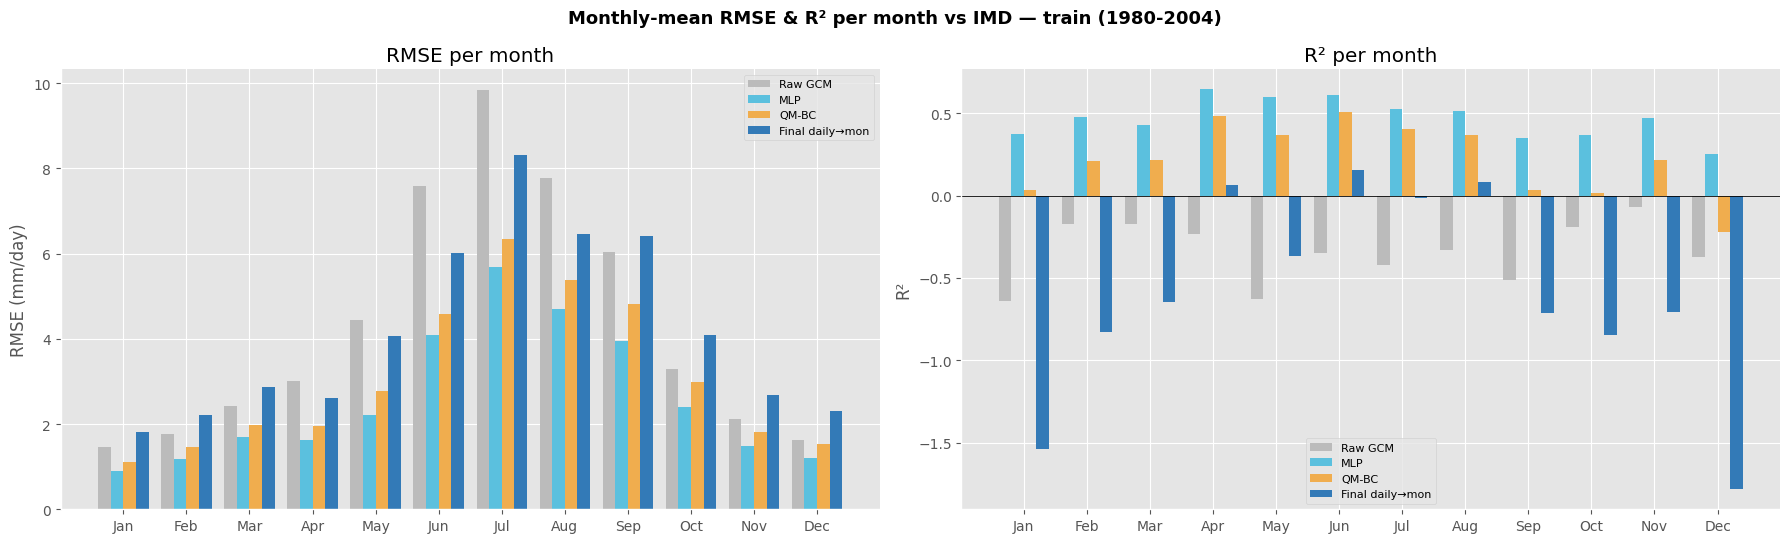

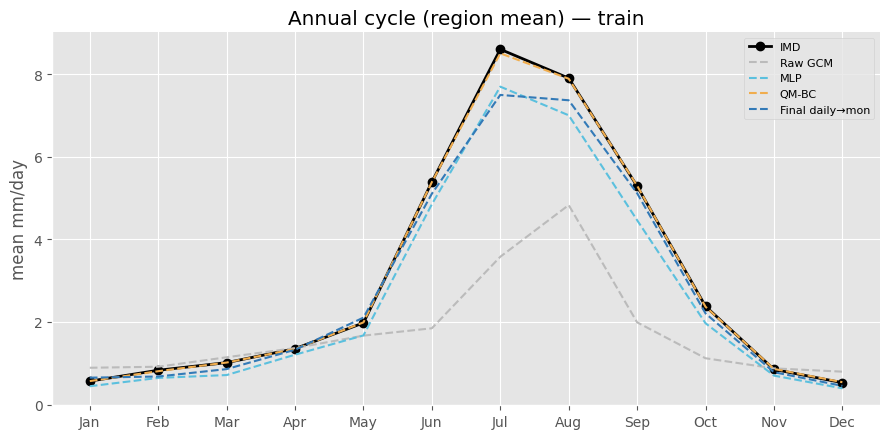


  EVALUATION — TEST  (2005-2014)

— Monthly-mean stage comparison (vs IMD) ----------------------
                          Raw GCM     MLP   QM-BC  Final daily→mon
MAE (monthly)              2.7621  1.6438  2.2571           2.5385
MSE (monthly)             29.4801 11.0253 19.2390          29.2640
RMSE (monthly)             5.4296  3.3204  4.3862           5.4096
R² (monthly)              -0.1247  0.5794  0.2660          -0.1164
KGE (monthly)              0.2381  0.6350  0.6424           0.4995
Spatial climatology corr      NaN     NaN     NaN              NaN
Annual cycle corr          0.9108  0.9956  0.9945           0.9916

— Daily metrics: final v5c product vs IMD daily ---------------
                  Final daily
MAE (daily)            4.6506
MSE (daily)          240.2296
RMSE (daily)          15.4993
R² (daily)            -1.0297
KGE (daily)            0.1112
KGE (JJAS daily)       0.0765
R² (JJAS daily)       -0.9866


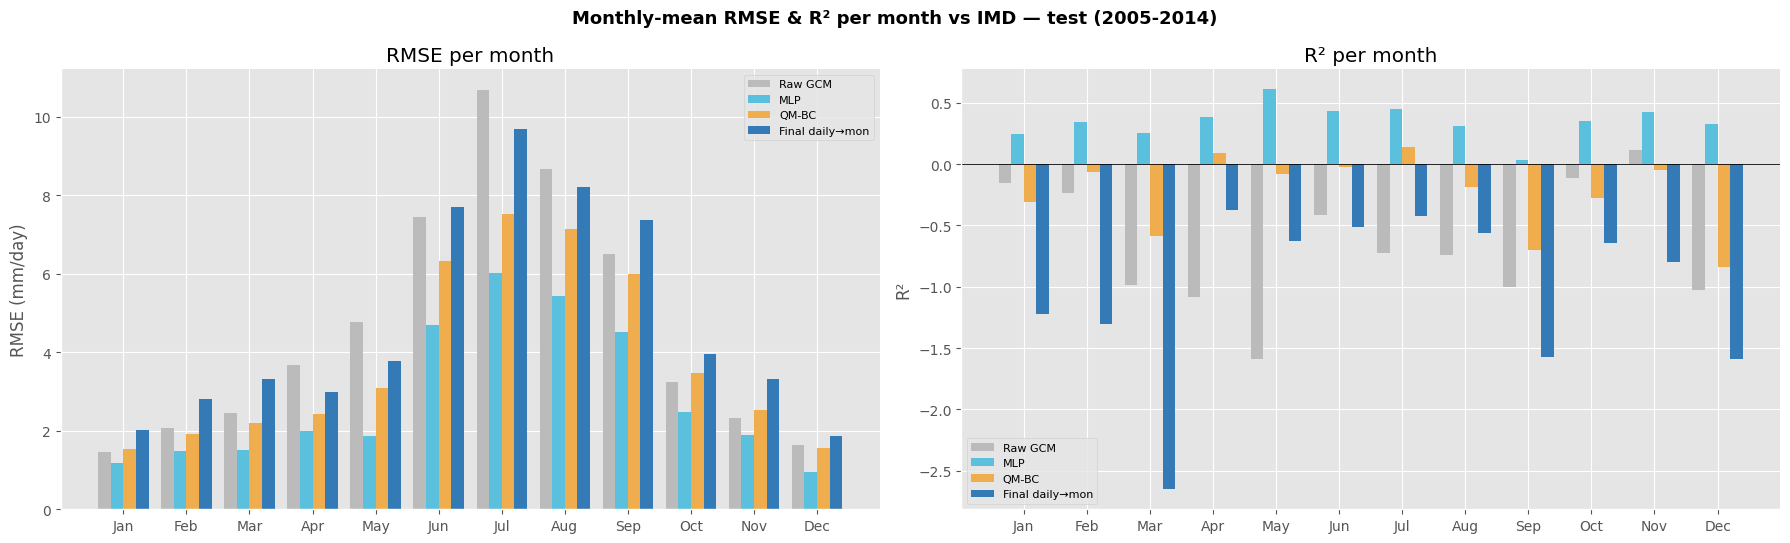

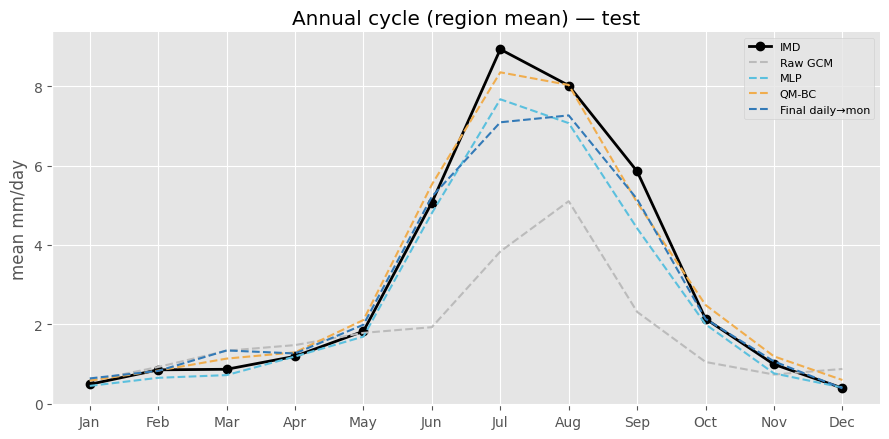

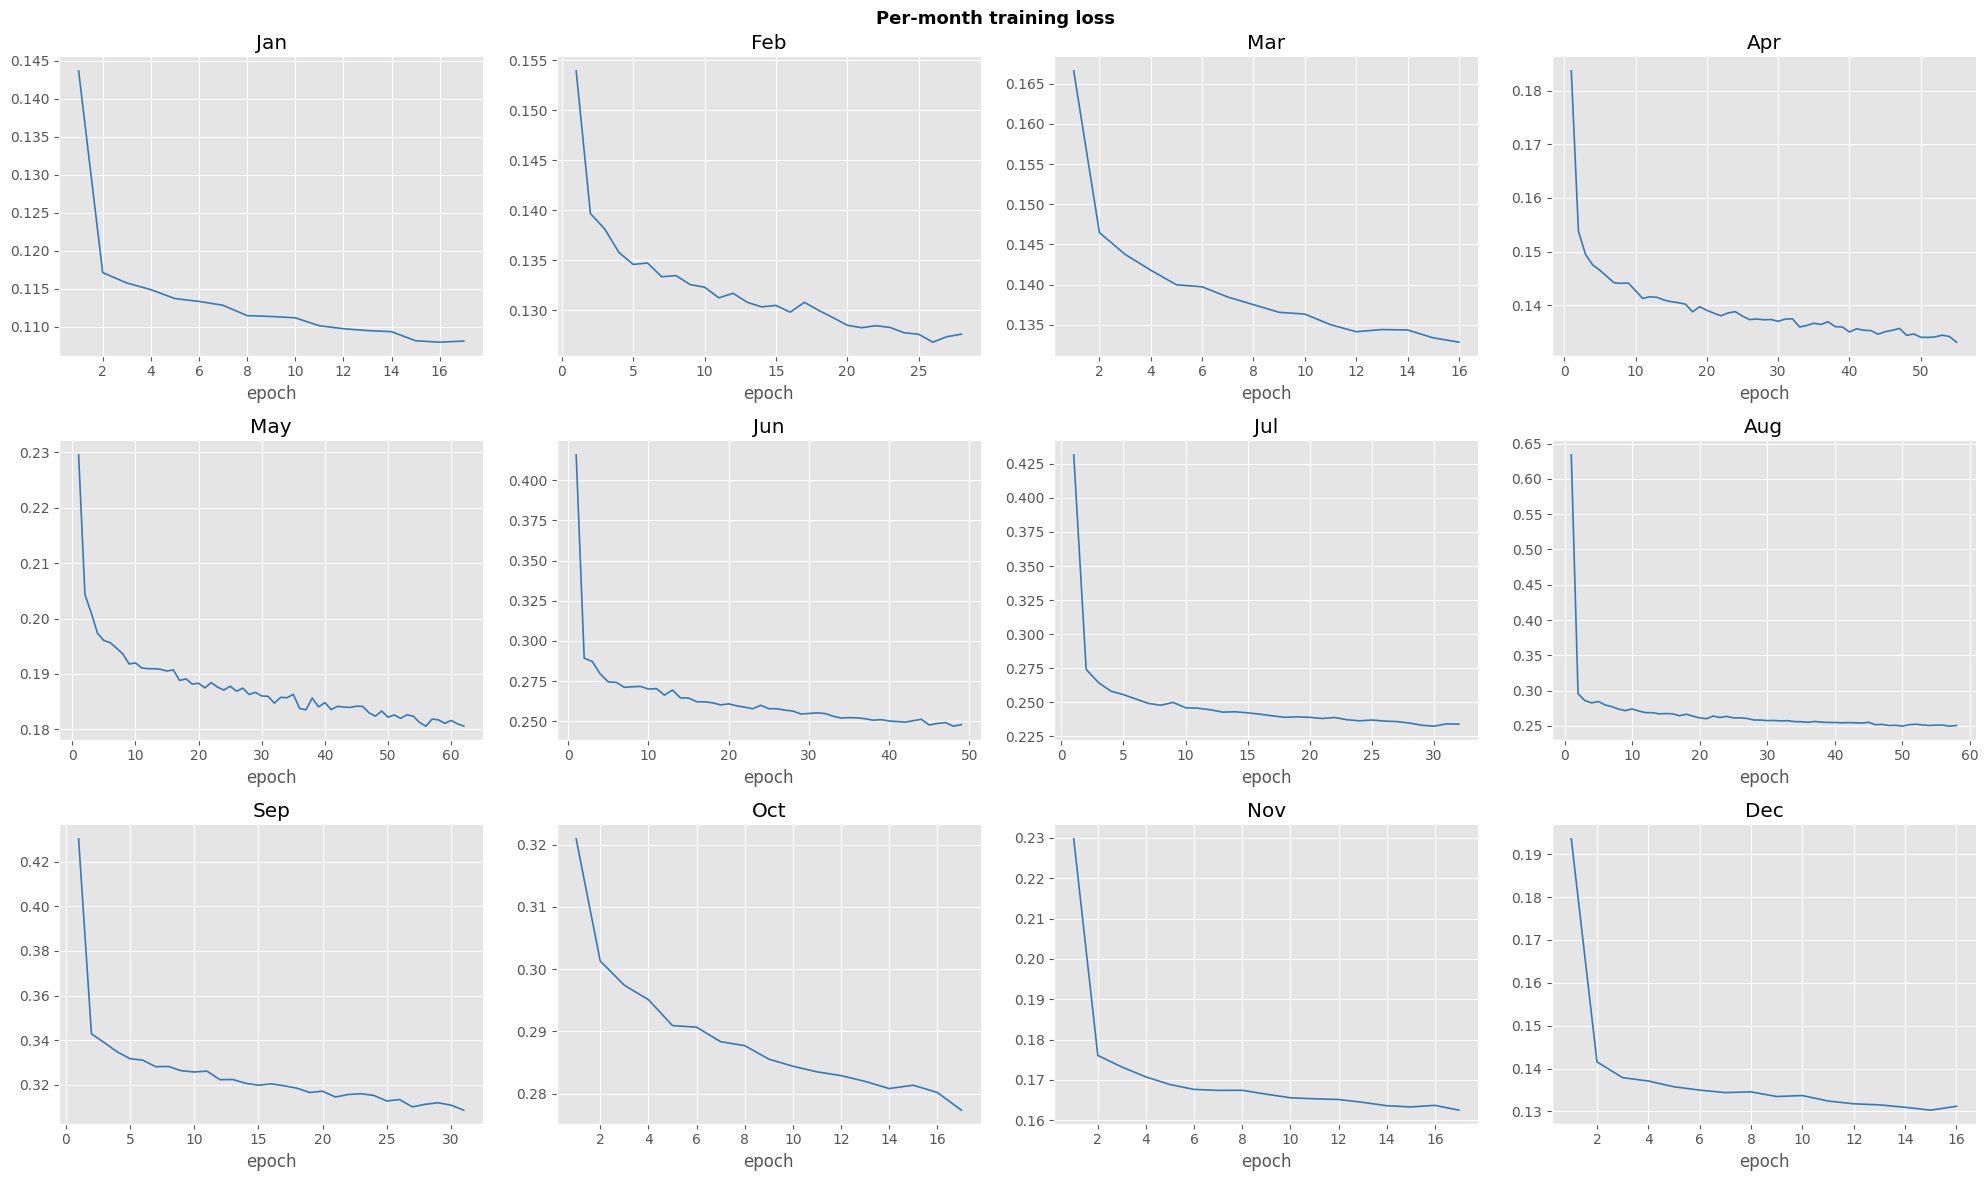

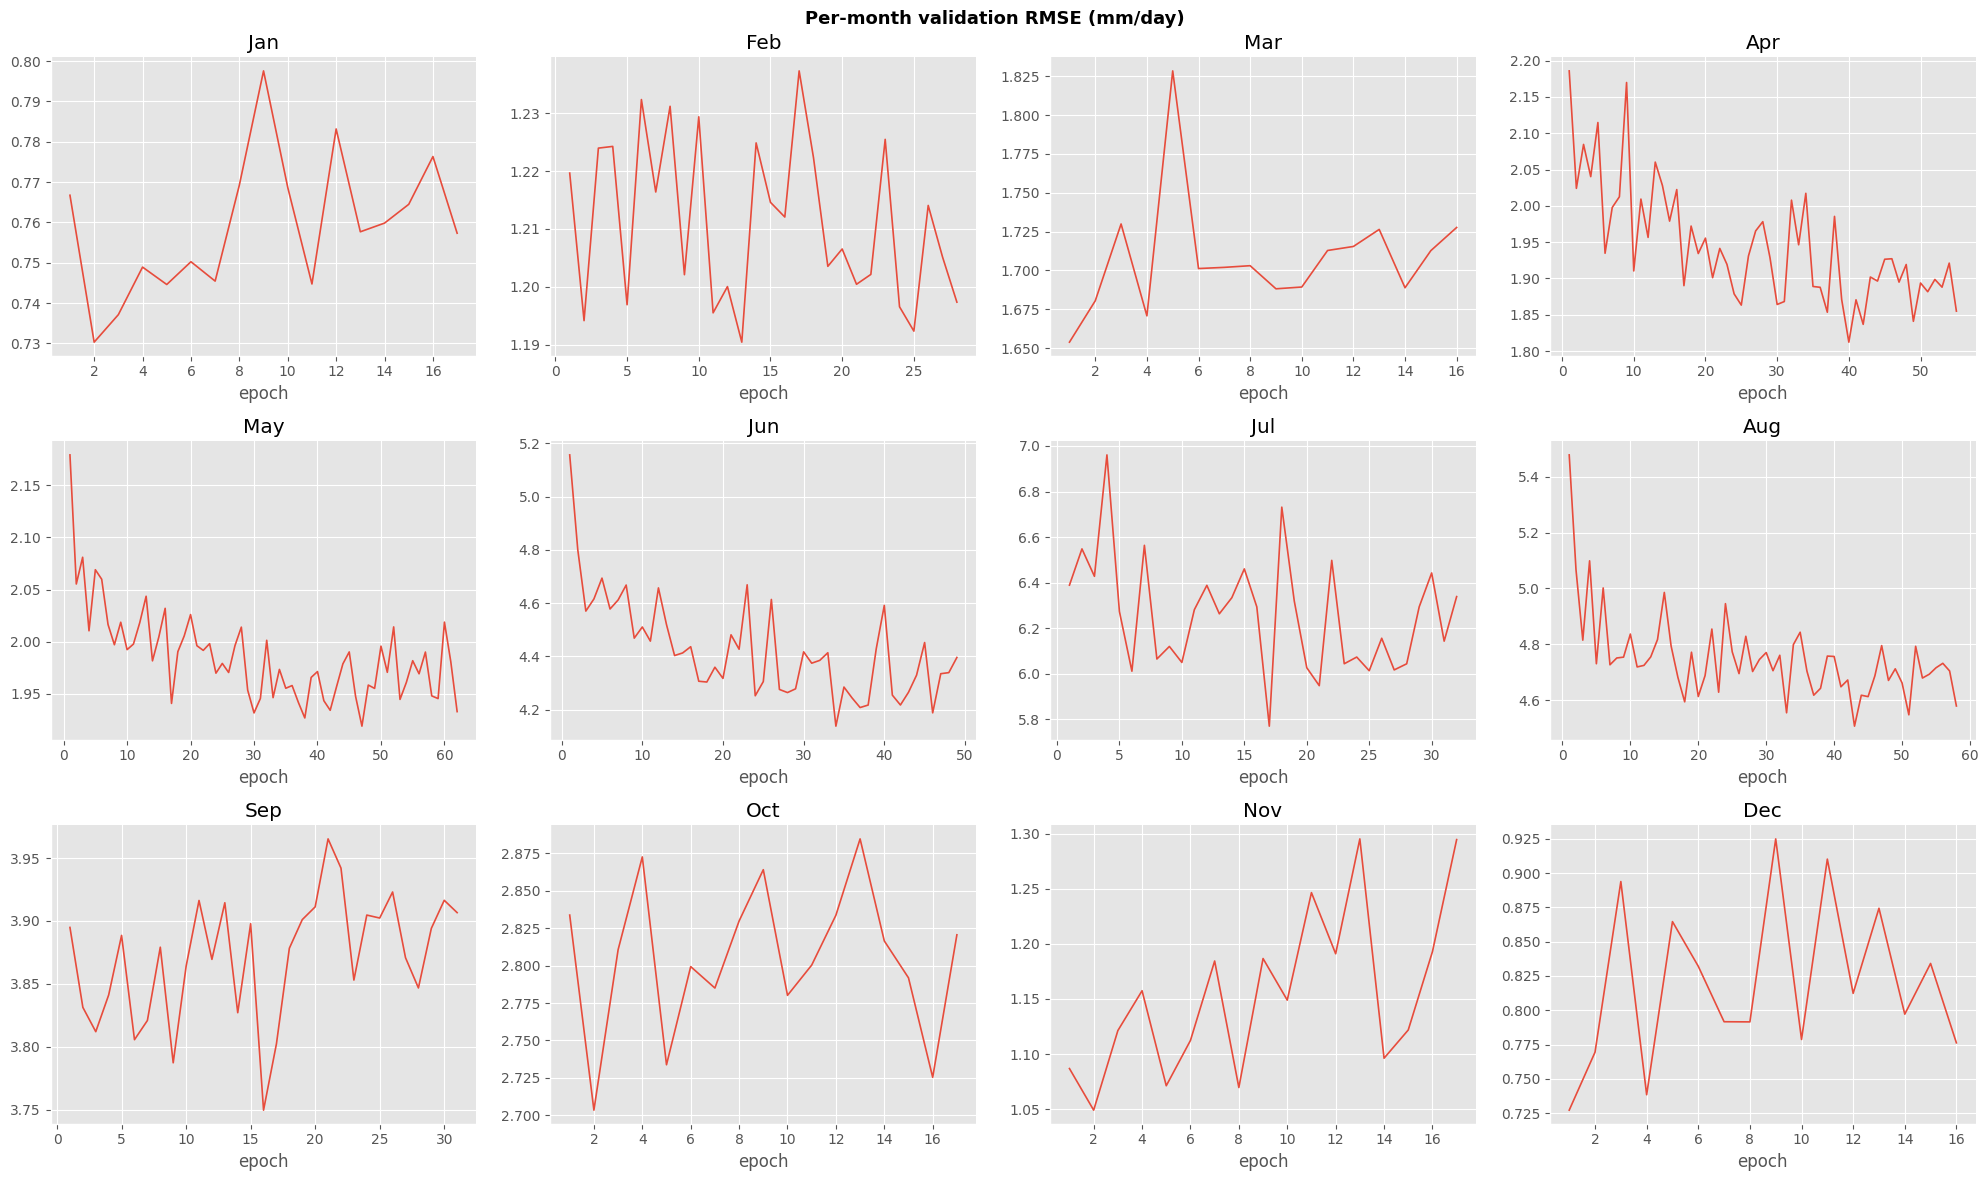


✅ Evaluation complete — tables + plots saved to /kaggle/working/india_monthly_downscaling/logs


In [28]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 13 — EVALUATION  (metrics + tables + plots)                      ║
# ║  Reference = IMD.  Stages: Raw GCM · MLP · QM-BC (monthly mean) and    ║
# ║  the final v5c product (daily). Standalone: reads saved NetCDFs.       ║
# ╚══════════════════════════════════════════════════════════════════════╝
# ── metric helpers (from the BCSD evaluation notebook) ───────────────────
def _rmse(o, p): return float(np.sqrt(np.mean((o - p) ** 2)))
def _mae (o, p): return float(np.mean(np.abs(o - p)))
def _mse (o, p): return float(np.mean((o - p) ** 2))
def _r2  (o, p):
    ss = np.sum((o - o.mean()) ** 2)
    return float(1 - np.sum((o - p) ** 2) / ss) if ss > 0 else np.nan
def _corr(o, p):
    if o.size < 2 or np.std(o) == 0 or np.std(p) == 0: return np.nan
    return float(np.corrcoef(o, p)[0, 1])
def _kge(o, p):
    if o.size < 2: return np.nan
    r = _corr(o, p)
    a = np.std(p) / np.std(o) if np.std(o) > 0 else np.nan
    b = np.mean(p) / np.mean(o) if np.mean(o) != 0 else np.nan
    if np.isnan(r) or np.isnan(a) or np.isnan(b): return np.nan
    return float(1 - np.sqrt((r - 1) ** 2 + (a - 1) ** 2 + (b - 1) ** 2))

# ── IMD daily reader (reuse Cell 12's if present) ────────────────────────
if "load_imd_daily" not in globals():
    def load_imd_daily(yr):
        ds = xr.open_dataset(IMD_FILES[yr]); da = ds[IMD_VAR]
        ren = {}
        if IMD_LAT  != "lat":  ren[IMD_LAT]  = "lat"
        if IMD_LON  != "lon":  ren[IMD_LON]  = "lon"
        if IMD_TIME != "time": ren[IMD_TIME] = "time"
        da = da.rename(ren).sortby("lat").sortby("lon")
        arr = _clean_fill(da.values); t = pd.to_datetime(da["time"].values)
        ds.close()
        return arr.astype("float32"), t

# ── monthly India-cell dicts  {(yr,month): (n_region,)} ──────────────────
def _gcm_monthly_india(years):
    out = {}
    for m in range(1, 13):
        g, tg = load_gcm_month(list(years), m)
        if g is None: continue
        for k, t in enumerate(tg): out[(t.year, m)] = g[k]
    return out

def _nc_monthly_india(nc, years):
    ds = xr.open_dataset(nc); pr = ds["pr"]
    t = pd.to_datetime(pr.time.values); vals = pr.values[:, ii_loc, jj_loc]; ds.close()
    return {(tt.year, tt.month): vals[k] for k, tt in enumerate(t) if tt.year in set(years)}

def _daily_to_monthly_india(daily_nc, years):
    ds = xr.open_dataset(daily_nc); pr = ds["pr"]
    t = pd.to_datetime(pr.time.values); vals = pr.values[:, ii_loc, jj_loc]; ds.close()
    out = {}
    for yr in years:
        for m in range(1, 13):
            sel = (t.year == yr) & (t.month == m)
            if sel.sum() > 0: out[(yr, m)] = np.nanmean(vals[sel], axis=0)
    return out

def _pair(stage, obs):
    O, P = [], []
    for k in sorted(set(stage) & set(obs)):
        oo, pp = obs[k], stage[k]
        v = np.isfinite(oo) & np.isfinite(pp) & (oo >= 0) & (pp >= 0)
        O.append(oo[v]); P.append(pp[v])
    return (np.concatenate(O), np.concatenate(P)) if O else (np.array([]), np.array([]))

def _clim_map(d):   return np.nanmean(np.vstack([d[k] for k in d]), axis=0)
def _annual_cycle(d):
    out = np.full(12, np.nan)
    for m in range(1, 13):
        vv = [np.nanmean(d[k]) for k in d if k[1] == m]
        if vv: out[m-1] = np.nanmean(vv)
    return out

# ── daily pairing of the final product vs IMD daily (date-aligned) ───────
def _daily_pairs(daily_nc, years):
    ds = xr.open_dataset(daily_nc); pr = ds["pr"]
    pred_t = pd.to_datetime(pr.time.values); pred = pr.values; ds.close()
    o_all, p_all, oj, pj = [], [], [], []
    for yr in years:
        if yr not in IMD_FILES: continue
        rf, obs_t = load_imd_daily(yr)
        if rf.shape[1:] != (nr_lat, nr_lon): continue
        psel = pred_t.year == yr
        pt = pred_t[psel]; pv = pred[psel]
        common = obs_t.intersection(pt)
        if len(common) == 0: continue
        oi = obs_t.get_indexer(common); pi = pt.get_indexer(common)
        o = rf[oi][:, ii_loc, jj_loc].ravel()
        p = pv[pi][:, ii_loc, jj_loc].ravel()
        v = np.isfinite(o) & np.isfinite(p) & (o >= 0) & (p >= 0)
        o_all.append(o[v]); p_all.append(p[v])
        jm = np.repeat(np.isin(common.month, [6,7,8,9]), n_region)[v]
        oj.append(o[v][jm]); pj.append(p[v][jm])
    return (np.concatenate(o_all), np.concatenate(p_all),
            np.concatenate(oj),    np.concatenate(pj))

# ── per-month daily metrics for a stage dict of (yr,m)->arrays vs obs ─────
def _per_month_monthly(stage, obs):
    res = {}
    for m in range(1, 13):
        oo = [obs[k]   for k in obs   if k[1] == m]
        pp = [stage[k] for k in stage if k[1] == m]
        ck = sorted(set(k for k in stage if k[1]==m) & set(k for k in obs if k[1]==m))
        if not ck: continue
        o = np.concatenate([obs[k]   for k in ck])
        p = np.concatenate([stage[k] for k in ck])
        v = np.isfinite(o)&np.isfinite(p)&(o>=0)&(p>=0)
        res[m] = (_rmse(o[v], p[v]), _r2(o[v], p[v]))
    return res

STAGE_FILES = {  # (monthly nc for MLP/BC differs train vs test)
    "train": dict(mlp=MLP_MON_TR, bc=BC_MON_TR, daily=DAILY_TR if "DAILY_TR" in globals()
                  else f"{OUT_DIR}/daily_train.nc"),
    "test":  dict(mlp=MLP_MON_TE, bc=BC_MON_TE, daily=DAILY_TE if "DAILY_TE" in globals()
                  else f"{OUT_DIR}/daily_test.nc"),
}
COL = {"raw":"Raw GCM", "mlp":"MLP", "bc":"QM-BC", "final":"Final daily→mon"}
CLR = {"raw":"#bbbbbb","mlp":"#5bc0de","bc":"#f0ad4e","final":"#337ab7","obs":"k"}

def evaluate(period, years):
    f = STAGE_FILES[period]
    print("\n" + "="*64 + f"\n  EVALUATION — {period.upper()}  ({min(years)}-{max(years)})\n" + "="*64)
    obs_m  = _nc_monthly_india(IMD_MONTHLY, years)
    stages = {"raw":   _gcm_monthly_india(years),
              "mlp":   _nc_monthly_india(f["mlp"], years),
              "bc":    _nc_monthly_india(f["bc"],  years),
              "final": _daily_to_monthly_india(f["daily"], years)}

    # ── Part A: monthly-mean stage table ─────────────────────────────────
    rowsA = ["MAE (monthly)","MSE (monthly)","RMSE (monthly)","R² (monthly)",
             "KGE (monthly)","Spatial climatology corr","Annual cycle corr"]
    tableA = {}
    acyc   = {"obs": _annual_cycle(obs_m)}
    for s in ["raw","mlp","bc","final"]:
        o, p = _pair(stages[s], obs_m)
        tableA[COL[s]] = [_mae(o,p), _mse(o,p), _rmse(o,p), _r2(o,p), _kge(o,p),
                          _corr(_clim_map(obs_m), _clim_map(stages[s])),
                          _corr(_annual_cycle(obs_m), _annual_cycle(stages[s]))]
        acyc[s] = _annual_cycle(stages[s])
    dfA = pd.DataFrame(tableA, index=rowsA)
    pd.set_option("display.float_format", lambda v: f"{v:.4f}")
    print("\n— Monthly-mean stage comparison (vs IMD) " + "-"*22)
    print(dfA.to_string())
    dfA.to_csv(f"{LOG_DIR}/metrics_monthly_{period}.csv")

    # ── Part B: daily metrics for the final v5c product ──────────────────
    od, pdl, oj, pj = _daily_pairs(f["daily"], years)
    rowsB = ["MAE (daily)","MSE (daily)","RMSE (daily)","R² (daily)","KGE (daily)",
             "KGE (JJAS daily)","R² (JJAS daily)"]
    valsB = [_mae(od,pdl),_mse(od,pdl),_rmse(od,pdl),_r2(od,pdl),_kge(od,pdl),
             _kge(oj,pj),_r2(oj,pj)]
    dfB = pd.DataFrame({"Final daily": valsB}, index=rowsB)
    print("\n— Daily metrics: final v5c product vs IMD daily " + "-"*15)
    print(dfB.to_string())
    dfB.to_csv(f"{LOG_DIR}/metrics_daily_{period}.csv")

    # ── Plot 1: per-month monthly RMSE & R² across stages ────────────────
    pm = {s: _per_month_monthly(stages[s], obs_m) for s in ["raw","mlp","bc","final"]}
    months = sorted(set().union(*[set(pm[s]) for s in pm])); x = np.arange(len(months)); w = 0.2
    fig, (axR, axS) = plt.subplots(1, 2, figsize=(18, 5.5))
    fig.suptitle(f"Monthly-mean RMSE & R² per month vs IMD — {period} "
                 f"({min(years)}-{max(years)})", fontsize=13, fontweight="bold")
    for i, s in enumerate(["raw","mlp","bc","final"]):
        axR.bar(x+(i-1.5)*w, [pm[s].get(m,(np.nan,np.nan))[0] for m in months], w,
                label=COL[s], color=CLR[s])
        axS.bar(x+(i-1.5)*w, [pm[s].get(m,(np.nan,np.nan))[1] for m in months], w,
                label=COL[s], color=CLR[s])
    for ax, ttl, yl in [(axR,"RMSE per month","RMSE (mm/day)"),(axS,"R² per month","R²")]:
        ax.set_xticks(x); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
        ax.set_title(ttl); ax.set_ylabel(yl); ax.legend(fontsize=8)
        ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)
    plt.tight_layout(); plt.savefig(f"{LOG_DIR}/bar_stages_{period}.png", dpi=150,
                                    bbox_inches="tight"); plt.show()

    # ── Plot 2: annual cycle (region mean) ───────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1,13), acyc["obs"], "k-o", lw=2, label="IMD")
    for s in ["raw","mlp","bc","final"]:
        ax.plot(range(1,13), acyc[s], "--", color=CLR[s], label=COL[s])
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES)
    ax.set_ylabel("mean mm/day"); ax.set_title(f"Annual cycle (region mean) — {period}")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{LOG_DIR}/annual_cycle_{period}.png", dpi=150,
                                    bbox_inches="tight"); plt.show()
    return dfA, dfB

# run for both periods
dfA_tr, dfB_tr = evaluate("train", TRAIN_YEARS)
dfA_te, dfB_te = evaluate("test",  TEST_YEARS)

# ── per-month training curves (from epoch logs saved in Cell 9) ──────────
def _curve(col, title, color, fname):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes = axes.ravel()
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes[m-1]; fp = f"{LOG_DIR}/epoch_metrics_m{m:02d}.csv"
        if os.path.exists(fp):
            d = pd.read_csv(fp)
            if col in d and d[col].notna().any(): ax.plot(d["epoch"], d[col], color=color, lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{LOG_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

_curve("train_loss", "Per-month training loss",            "#337ab7", "loss_curves.png")
_curve("val_rmse",   "Per-month validation RMSE (mm/day)", "#e74c3c", "val_rmse_curves.png")

print("\n✅ Evaluation complete — tables + plots saved to", LOG_DIR)

In [29]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 14 — Zip everything for download                                ║
# ╚══════════════════════════════════════════════════════════════════════╝
import shutil
zip_path = shutil.make_archive("/kaggle/working/india_monthly_results", "zip", OUT_DIR)
print(f"✅ {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("Download from the Output panel. Keep optuna_study.db + final_config.json")
print("if you ever want to resume tuning or reproduce the run.")

✅ /kaggle/working/india_monthly_results.zip  (100.7 MB)
Download from the Output panel. Keep optuna_study.db + final_config.json
if you ever want to resume tuning or reproduce the run.
